## Fully Connected Neuronal Net (FCNN) am Beispiel des MNIST - Datensatzes

Als Beispiel für ein Fully Connected Neuronal Net (FCNN) wird der MNIST - Datensatz verwendet. Dieser Datensatz besteht aus handgeschriebenen Ziffern (0-9) und ist ein Standard-Datensatz für die Evaluierung von Bildklassifikationsalgorithmen.

In [1]:
#load modules


import numpy as np
import os

import datetime
import matplotlib.pyplot as plt
#--------------------------------------------------
# TensorFlow import
#-------------------------------------------------
import tensorflow as tf
from tensorflow.keras.models import Sequential
import tensorflow.python.util.deprecation as deprecation
deprecation._PRINT_DEPRECATION_WARNINGS = False

import modules.matrixPlotting

##### Laden des MNIST - Datensatzes

Der Datsatz kann direkt über die Bibliothek `tensorflow` geladen werden. Dabei werden die Bilder in Trainings- und Testdaten aufgeteilt. Jedes Bild hat eine Größe von 28x28 Pixeln und ist in Graustufen.

In [2]:
#--------------------------------------------------
# Load MNIST-Datensatzes Dataset using Keras
#--------------------------------------------------
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [3]:
# Analyze and investigate data Structure
print(f"Trainingsdaten: {X_train.shape}, Labels: {y_train.shape}")



Trainingsdaten: (60000, 28, 28), Labels: (60000,)


##### Anzeige der Daten

Jede Ziffer wird einmal angezeigt

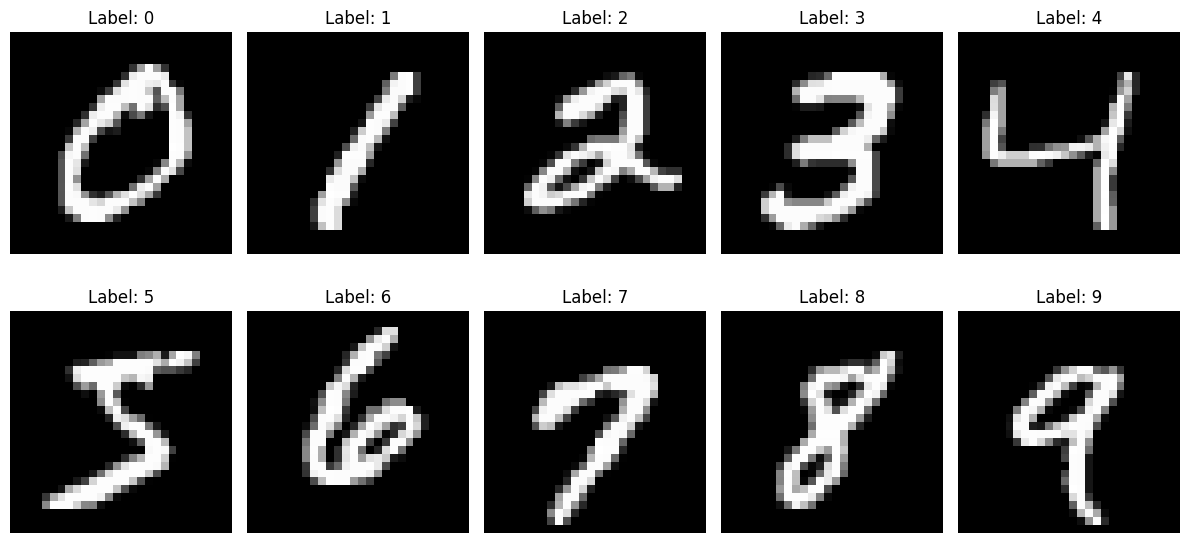

In [4]:
# Create a figure to display the images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel() # Flatten the 2x5 grid into a 1D array

# Loop through each digit from 0 to 9
for i in range(10):
    # Find the first index of the current digit in the training labels
    idx = np.where(y_train == i)[0][0]
    
    # Get the corresponding image from the training data
    image = X_train[idx]
    
    # Display the image on the appropriate subplot
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"Label: {i}")
    axes[i].axis('off') # Hide the axes

plt.tight_layout()
plt.show()

In [7]:
print(y_train[4])

9


##### Vorbereitung der Daten 

Die Daten müssen für die Eingabe in das FCNN vorbereitet werden. Dazu werden die 28x28 Pixel großen Bilder in Vektoren der Länge 784 (28*28) umgewandelt. Außerdem werden die Pixelwerte normalisiert, indem sie durch 255 geteilt werden, um Werte zwischen 0 und 1 zu erhalten.

Die Labels werden in eine One-Hot_Kodieriung umgewandelt. D.h. die Labels (Ziffern 0-9) werden in einen binären Vektor der Länge 10 umgewandelt, wobei die Position der Ziffer auf 1 gesetzt wird und alle anderen Positionen auf 0. Zum Beispiel wird die Ziffer '3' als [0, 0, 0, 1, 0, 0, 0, 0, 0, 0] kodiert.

In [8]:
#--------------------------------------------------
# Flatten
#--------------------------------------------------
X_train = X_train.reshape(-1, 28 * 28)
X_test  = X_test.reshape(-1, 28 * 28)

#--------------------------------------------------
# Normieren
#--------------------------------------------------
X_train   = X_train / 255
X_test  = X_test  / 255

#--------------------------------------------------
# One-Hot-Kodierung
#--------------------------------------------------
y_train_oneHot = tf.keras.utils.to_categorical(y_train, 10)
y_test_oneHot = tf.keras.utils.to_categorical(y_test, 10)

##### Anzeigen der abgewandelten Datenstruktur

In [9]:
print(f"Trainingsdaten: {X_train.shape}, Labels: {y_train_oneHot.shape}")

print(f"One-Hot-Encoding: \n {y_train_oneHot[0:10,:]}")

print(f"Beispiel-Bild (Ausschnitt): \n {X_train[55][200:250]}")

Trainingsdaten: (60000, 784), Labels: (60000, 10)
One-Hot-Encoding: 
 [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]
Beispiel-Bild (Ausschnitt): 
 [0.         0.         0.         0.         0.         0.
 0.         0.03137255 0.37254902 0.85098039 0.99215686 0.99215686
 0.99215686 0.99215686 0.99215686 0.99215686 0.99215686 0.99215686
 0.99215686 0.97254902 0.04313725 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.10588235 0.83529412
 0.99215686 0.99215686 0.94117647 0.56078431 0.43529412 0.59607843
 0.99215686 0.99215686 0.99215686 0.99215686 0.76078431 0.24313725
 0.         0.        ]


In [10]:
#- Define and KERAS / TensorFlow Sequential Model)
###########

# define initila values initializers
init_kernel = tf.keras.initializers.RandomNormal(mean=0., stddev=1.)
init_bias   = tf.keras.initializers.RandomNormal(mean=0., stddev=1.)



# Create a sequential model
model_fcn = Sequential()
# input layer with 784 neurons (28*28)
model_fcn.add(tf.keras.Input(shape=(28*28,)))

# hidden layers fully connected 64 neurons
model_fcn.add(tf.keras.layers.Dense(64, activation="sigmoid", kernel_initializer = init_kernel, bias_initializer = init_bias))

# hidden layers fully connected 32 neurons
model_fcn.add(tf.keras.layers.Dense(32, activation="sigmoid",kernel_initializer = init_kernel, bias_initializer = init_bias))

# output layer with 10 neurons (10 classes for digits 0-9)
model_fcn.add(tf.keras.layers.Dense(10, activation="sigmoid",kernel_initializer = init_kernel, bias_initializer = init_bias))

model_fcn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
#--------------------------------------------------
# define custom MSE loss function  
#--------------------------------------------------
def my_mse(y_true,y_pred):
    L = tf.reduce_mean(tf.square(tf.subtract(y_true,y_pred)))
    return L

#### Hyperparameter definieren und Modell trainieren

In [12]:
#--------------
# define hyperparameters
#--------------

# packet size how many images are passed through the network at once
batch_size = 35 

# number of training iterations
epochs = 80

# learning rate for optimizer (how fast the model adjust its weights during backpropagation)
learning_rate = 0.7

# split between training and validation data
validation_split = 0.1  

# loss function
loss = 'MeanSquaredError'

# metric to evaluate model performance
metrics = ['accuracy']




#--------------------------------------------------
# Modell kompilieren
#------------------------------------------------

model_fcn.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate), loss=loss, metrics=metrics)

#--------------------------------------------------
# Modell trainieren
#--------------------------------------------------
history_fcn = model_fcn.fit(X_train, y_train_oneHot, batch_size=batch_size, epochs=epochs,  validation_split=validation_split, verbose=1,)

Epoch 1/80
1543/1543 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7085 - loss: 0.0439 - val_accuracy: 0.7607 - val_loss: 0.0382
Epoch 2/80
1543/1543 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7457 - loss: 0.0393 - val_accuracy: 0.7925 - val_loss: 0.0342
Epoch 3/80
1543/1543 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7722 - loss: 0.0357 - val_accuracy: 0.8142 - val_loss: 0.0310
Epoch 4/80
1543/1543 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7926 - loss: 0.0329 - val_accuracy: 0.8300 - val_loss: 0.0284
Epoch 5/80
1543/1543 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8095 - loss: 0.0305 - val_accuracy: 0.8455 - val_loss: 0.0263
Epoch 6/80
1543/1543 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8237 - loss: 0.0286 - val_accuracy: 0.8530 - val_loss: 0.0246
Epoch 7/80
1543/1543 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8343 - loss: 0.0269 - val_accuracy: 0.8612 - val_loss: 0.0232
Epoch 8/80
1543/1543 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8425 - loss: 0.0256 - 

##### Darstellung des Trainingsverlaufs

Klassifikationsgenauigkeit und Fehler als Funktion der Epochen darstellen.

------------------------------------------
Klassifikationsgenauigkeit (Trainingsende)
------------------------------------------
94.32963132858276  Prozent


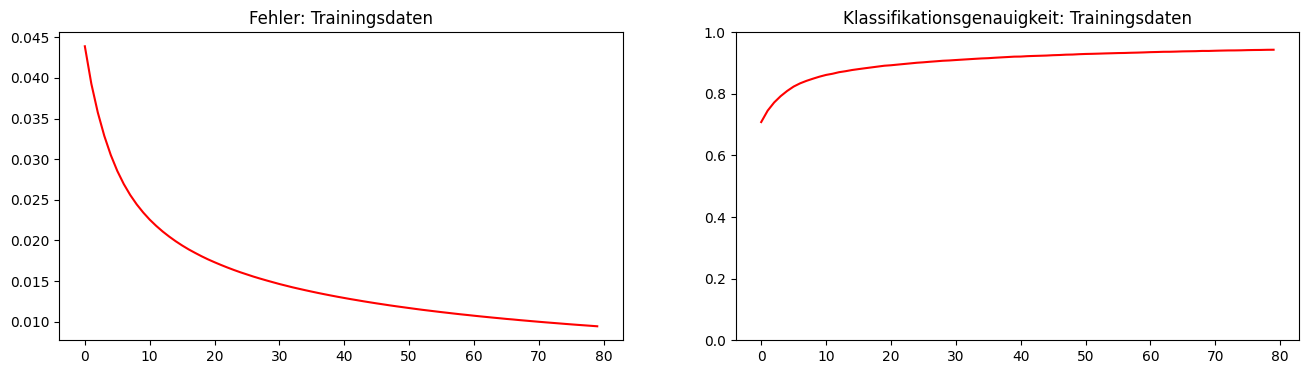

In [13]:
fig, ax = plt.subplots(1,2, squeeze=False,figsize=(16, 4))

ax[0,0].plot(history_fcn.history['loss'],"r")
ax[0,1].plot(history_fcn.history['accuracy'],"r")
ax[0,1].set_ylim([0,1])


ax[0,0].set_title("Fehler: Trainingsdaten")
t=ax[0,1].set_title("Klassifikationsgenauigkeit: Trainingsdaten")

print("------------------------------------------")
print("Klassifikationsgenauigkeit (Trainingsende)")
print("------------------------------------------")
print(np.max(history_fcn.history['accuracy'])*100 , " Prozent")

### Modell auf Testdaten anwenden

In [14]:
# apply model to test data. Classification
test_loss, test_accuracy = model_fcn.evaluate(X_test, y_test_oneHot, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9269 - loss: 0.0113


In [15]:
print("------------------------------------------")
print("Klassifikationsgenauigkeit Testdate )")
print("------------------------------------------")
print(test_accuracy*100 , " Prozent")


------------------------------------------
Klassifikationsgenauigkeit Testdate )
------------------------------------------
92.69000291824341  Prozent


##### Beispielhafte Vorhersagen anzeigen

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


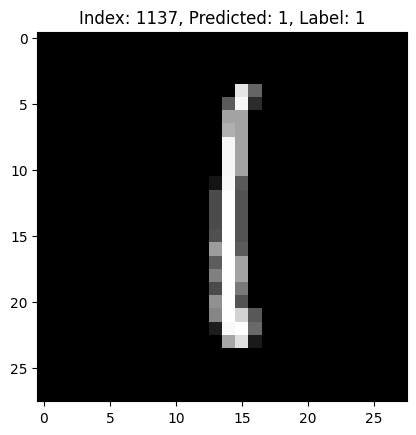

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


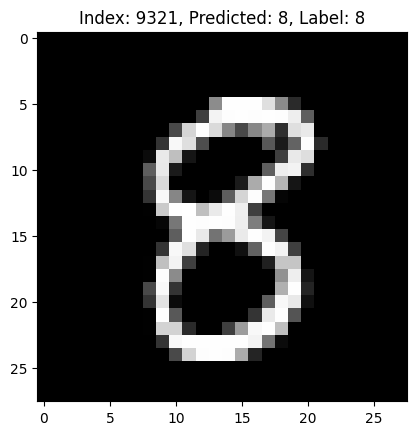

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


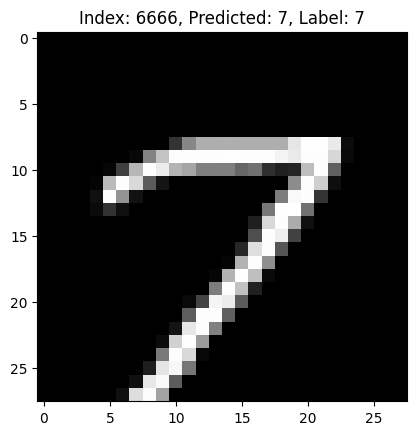

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


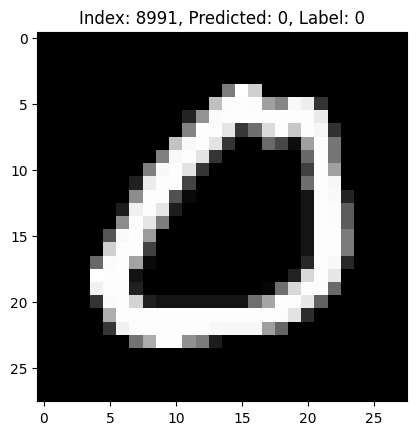

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


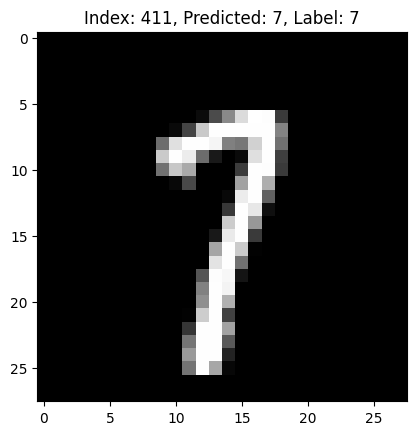

In [13]:
# 10 random numbers from test set
random_indices = np.random.randint(0, X_test.shape[0], size=5)

for index in random_indices:
    example_image = X_test[index,:].reshape(1,28*28)
    example_label = y_test[index]
    example_prediction = model_fcn.predict(example_image)
    predicted_label = np.argmax(example_prediction)

    #print(f'index {index}')
    #print(f'predicted {predicted_label}')
    #print(f'actual {example_label}')

    plt.figure()
    plt.imshow(example_image.reshape(28,28), cmap='gray')
    plt.title(f'Index: {index}, Predicted: {predicted_label}, Label: {example_label}')
    plt.show()


##### Fehlerhafte Vorhersagen anzeigen

In [14]:
# identify and print misclassified examples
predictions = model_fcn.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
misclassified_indices = np.where(predicted_labels != y_test)[0]
print(f'Anzahl falsch klassifizierter Objekte: {misclassified_indices.shape}')
print(predictions.shape)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 861us/step
Anzahl falsch klassifizierter Objekte: (615,)
(10000, 10)


Falsche Klassifizierungen: 615


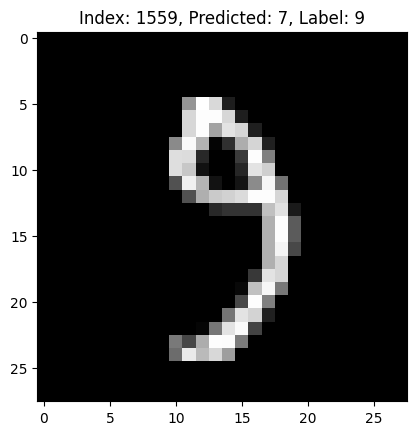

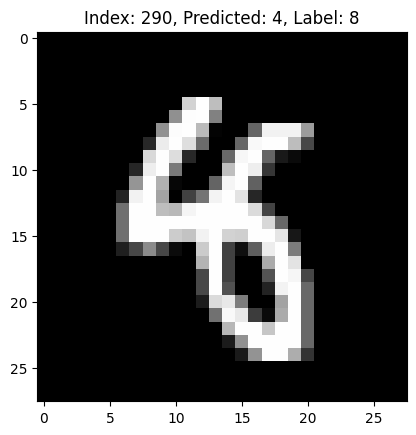

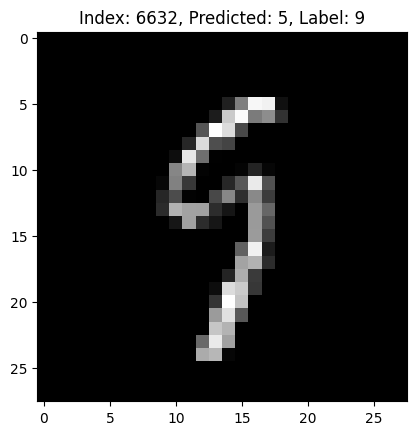

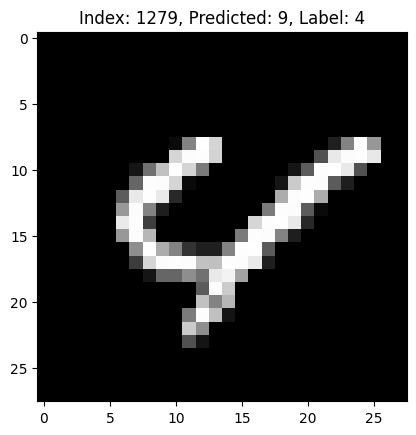

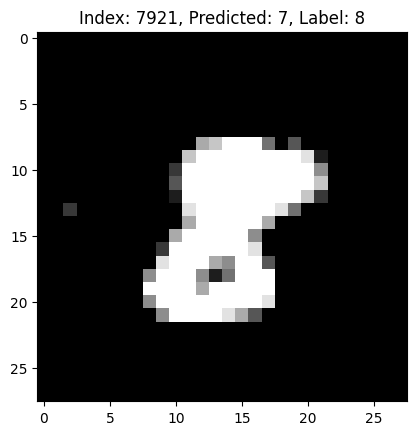

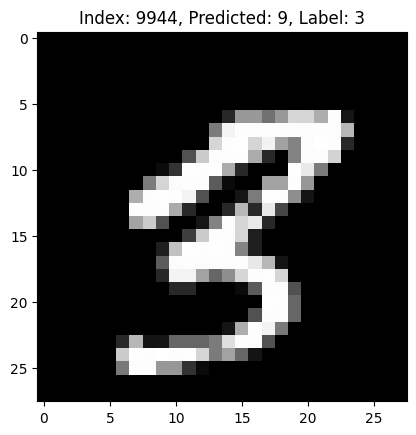

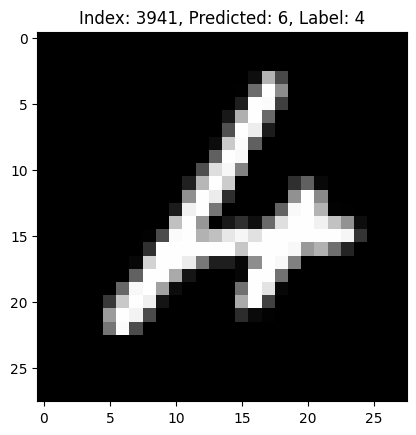

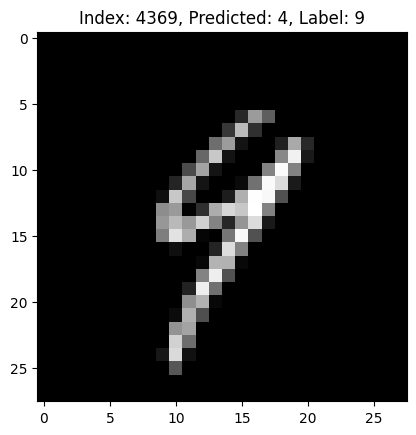

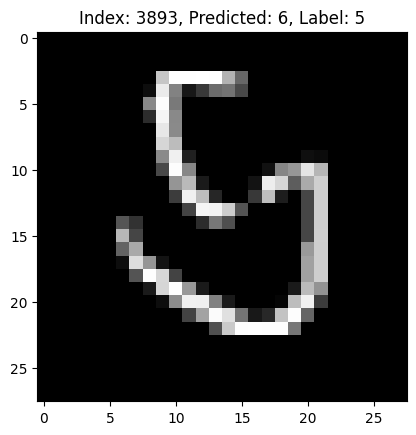

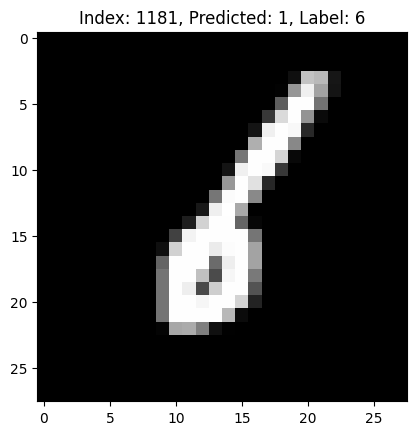

In [15]:
print(f'Falsche Klassifizierungen: {misclassified_indices.shape[0]}')


# print number of misclassified examples
indices = np.random.randint(0, misclassified_indices.shape[0], size=10)
indices = misclassified_indices[indices]

for index in indices:
    example_image = X_test[index,:].reshape(28,28)
    predicted_label = predicted_labels[index]
    actual_label = y_test[index]

    plt.figure()
    plt.imshow(example_image, cmap='gray')
    plt.title(f'Index: {index}, Predicted: {predicted_label}, Label: {actual_label}')
    plt.show()

##### Confusion Matrix anzeigen

In [16]:
cMat_test = tf.math.confusion_matrix(
    predicted_labels,
    y_test,
    num_classes=None,
    weights=None,
    dtype=tf.dtypes.int32,
    name=None
)


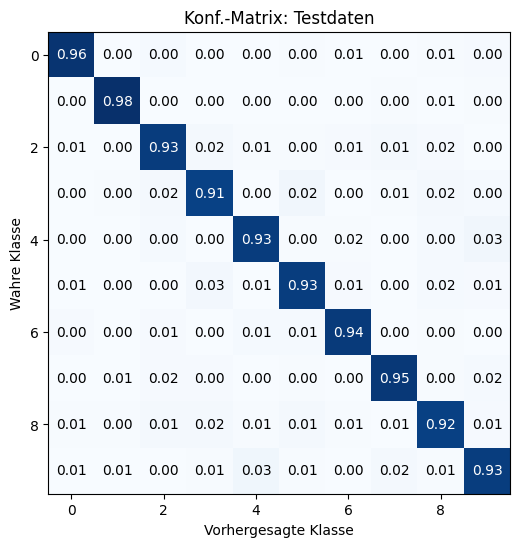

In [17]:
fig, ax_ = plt.subplots(1,1, squeeze=False,figsize=(6, 6))
#----------------------------------
# Konfusionsmatrix ausgeben
#----------------------------------
modules.matrixPlotting.plotConfusionMatrix(cMat_test,  True, ax_[0,0],txt="Konf.-Matrix: Testdaten") 